In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILE_PATH = "/content/drive/MyDrive/derived_feature_table.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (239, 20)


,feature label,population_proxy,total_family_households,insurance_rate,uninsured_rate,poverty_rate,housing_cost_burden_rate,bachelors_or_higher_rate,low_education_rate,some_college_or_higher_rate,married_household_share,single_parent_household_share,single_female_household_share,mh_provider_per_capita,health_workers_per_capita,female_provider_share,male_provider_share,mh_provider_share_of_health_workers,environmental_risk_index,Poor Mental Health Among Adults (2023)
0,"Council District 5, Austin, TX",96047.4967,22382.2697,0.896533,0.103467,0.101014,0.169311,0.469009,0.036170,0.648305,0.781888,0.218112,0.147156,0.002207,0.022531,0.740566,0.240566,0.097967,11.88380,16.1234
1,"Council District 6, Austin, TX",97237.0521,25400.3965,0.925528,0.074472,0.061303,0.142338,0.482590,0.029052,0.625213,0.802484,0.197516,0.124169,0.000998,0.018244,0.773196,0.226804,0.054679,0.71760,14.5732
2,"Council District 7, Austin, TX",97170.1722,21568.1097,0.903577,0.096423,0.085793,0.190289,0.494706,0.031509,0.661511,0.796041,0.203959,0.136881,0.001204,0.031110,0.769231,0.222222,0.038703,10.62340,15.9657
3,"Council District 10, Austin, TX",97999.6090,25102.5521,0.938883,0.061117,0.058964,0.164023,0.556008,0.010911,0.676690,0.852889,0.147111,0.108762,0.006612,0.073990,0.751543,0.248457,0.089367,8.64060,13.7408
4,"Council District 1, Austin, TX",104666.2740,23740.7967,0.840947,0.159053,0.159254,0.163991,0.342878,0.084443,0.501816,0.661941,0.338059,0.260879,0.000965,0.009822,0.752475,0.247525,0.098249,20.23935,17.7182


In [ ]:
# --- Preprocessing WITH ID tracking + missing value handling ---

import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

df_model = df.copy()

# ------------------------------------------------
# 1. Save ID + target separately
# ------------------------------------------------
ids = df_model['feature label'] if 'feature label' in df_model.columns else None
target_col = 'Poor Mental Health Among Adults (2023)'
target = df_model[target_col] if target_col in df_model.columns else None

# ------------------------------------------------
# 2. Define columns to drop
# ------------------------------------------------
cols_to_drop = [
    'feature label',
    'Poor Mental Health Among Adults (2023)',

    # Redundant / inverse features
    'uninsured_rate',
    'married_household_share',
    'low_education_rate',
    'some_college_or_higher_rate',

    # Weak / near-zero signal features
    'mh_provider_per_capita',
    'female_provider_share',
    'male_provider_share',
    'population_proxy',
    'total_family_households'
]

# Drop only columns that exist
df_model = df_model.drop(columns=[col for col in cols_to_drop if col in df_model.columns])

# ------------------------------------------------
# 3. Keep only numeric columns
# ------------------------------------------------
X = df_model.select_dtypes(include=['number']).copy()

print("Remaining numeric features:")
print(X.columns.tolist())
print(f"\nShape before imputation/scaling: {X.shape}")

# ------------------------------------------------
# 4. Check missing values before imputation
# ------------------------------------------------
missing_before = X.isna().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("\nMissing values before imputation:")
display(missing_before if len(missing_before) > 0 else pd.Series(dtype='int64'))

# ------------------------------------------------
# 5. Impute missing values using median
# ------------------------------------------------
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)

# ------------------------------------------------
# 6. Scale features
# ------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed_df)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# ------------------------------------------------
# 7. Reattach ID + target for interpretation only
# ------------------------------------------------
df_cluster_ready = X_scaled_df.copy()

if ids is not None:
    df_cluster_ready['feature label'] = ids.values

if target is not None:
    df_cluster_ready[target_col] = target.values

# ------------------------------------------------
# 8. Final checks
# ------------------------------------------------
print("\nAny missing values after imputation/scaling?")
print(X_scaled_df.isna().sum().sum())

print("\nFeature matrix shape:", X_scaled_df.shape)
print("Cluster-ready dataframe shape:", df_cluster_ready.shape)

display(df_cluster_ready.head())

Remaining numeric features:
['insurance_rate', 'poverty_rate', 'housing_cost_burden_rate', 'bachelors_or_higher_rate', 'single_parent_household_share', 'single_female_household_share', 'health_workers_per_capita', 'mh_provider_share_of_health_workers', 'environmental_risk_index']

Shape before imputation/scaling: (239, 9)

Missing values before imputation:


,0
mh_provider_share_of_health_workers,4



Any missing values after imputation/scaling?
0

Feature matrix shape: (239, 9)
Cluster-ready dataframe shape: (239, 11)


,insurance_rate,poverty_rate,housing_cost_burden_rate,bachelors_or_higher_rate,single_parent_household_share,single_female_household_share,health_workers_per_capita,mh_provider_share_of_health_workers,environmental_risk_index,feature label,Poor Mental Health Among Adults (2023)
0,-0.174565,-0.502408,0.618855,1.268132,-0.832708,-0.835729,-0.311443,0.269272,-0.859494,"Council District 5, Austin, TX",16.1234
1,0.352218,-1.074514,-0.032816,1.364135,-0.992513,-1.056723,-0.380413,-0.504226,-1.117410,"Council District 6, Austin, TX",14.5732
2,-0.046589,-0.721695,1.125704,1.449777,-0.942520,-0.934509,-0.173391,-0.789684,-0.888607,"Council District 7, Austin, TX",15.9657
3,0.594858,-1.108221,0.491103,1.883120,-1.383594,-1.204844,0.516556,0.115606,-0.934405,"Council District 10, Austin, TX",13.7408
4,-1.184474,0.336663,0.490316,0.376517,0.097947,0.257598,-0.515931,0.274316,-0.666498,"Council District 1, Austin, TX",17.7182


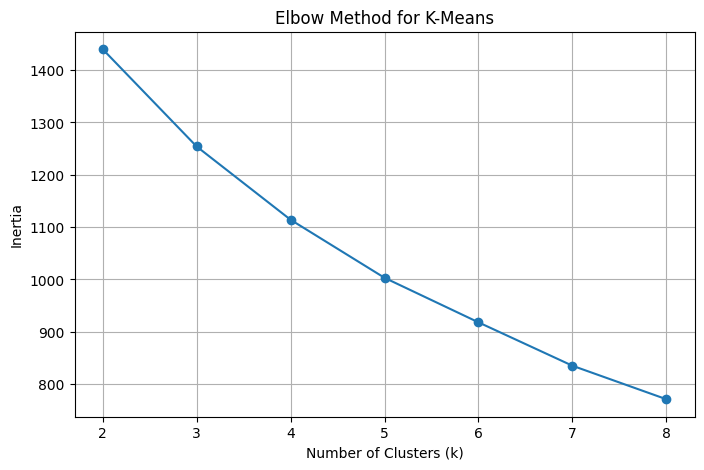

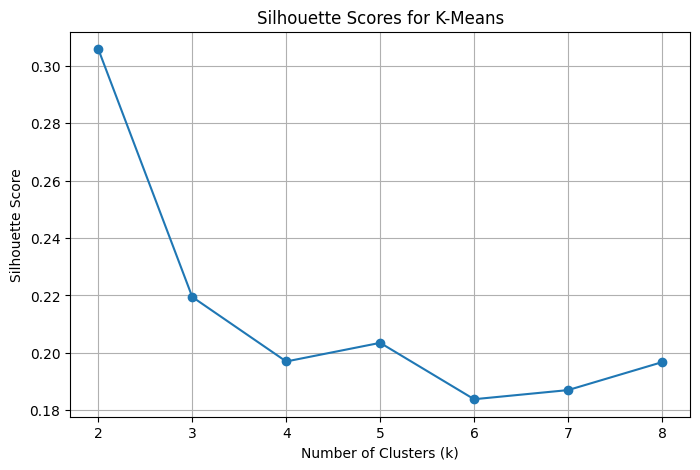

K comparison table:


,k,inertia,silhouette_score
0,2,1439.927451,0.305706
1,3,1254.007029,0.219472
2,4,1113.977946,0.197019
3,5,1003.035348,0.203508
4,6,917.902390,0.183882
5,7,834.971778,0.187059
6,8,770.957732,0.196774



Best k by silhouette score: 2

Cluster counts:


,count
cluster,
0,40
1,49
2,60
3,90



Average Poor Mental Health Among Adults (2023) by cluster:


...


Cluster profile table (mean standardized values):


,insurance_rate,poverty_rate,housing_cost_burden_rate,bachelors_or_higher_rate,single_parent_household_share,single_female_household_share,health_workers_per_capita,mh_provider_share_of_health_workers,environmental_risk_index
cluster,,,,,,,,,
0,-0.371,1.493,0.813,-0.762,1.539,1.569,0.271,0.244,1.530
1,0.800,-0.969,-1.197,0.038,-0.919,-0.902,-0.293,-0.547,-0.604
2,0.487,-0.637,0.385,1.285,-0.817,-0.760,0.366,0.277,-0.437
3,-0.596,0.288,0.033,-0.539,0.361,0.300,-0.205,0.005,-0.060



Sample labeled districts:


,feature label,cluster,Poor Mental Health Among Adults (2023)
0,"Council District 5, Austin, TX",2,16.1234
1,"Council District 6, Austin, TX",2,14.5732
2,"Council District 7, Austin, TX",2,15.9657
3,"Council District 10, Austin, TX",2,13.7408
4,"Council District 1, Austin, TX",3,17.7182
5,"Council District 2, Austin, TX",3,18.2050
6,"Council District 3, Austin, TX",3,18.9685
7,"Council District 4, Austin, TX",3,19.2139
8,"Council District 8, Austin, TX",2,14.1056
9,"Council District 9, Austin, TX",2,19.7536



Done. Use 'df_cluster_results' for interpretation and reporting.


In [ ]:
# --- K-Means clustering workflow: elbow + silhouette + final clusters ---
# Assumes you already ran the preprocessing cell and have:
#   1) X_scaled_df         -> scaled numeric features only
#   2) df_cluster_ready    -> scaled features + feature label + target

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------------------------------------
# 1. Choose range of K values to test
# -------------------------------------------------
k_values = range(2, 9)

inertias = []
silhouette_scores = []

X = X_scaled_df.copy()

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, cluster_labels))

# -------------------------------------------------
# 2. Plot elbow curve
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

# -------------------------------------------------
# 3. Plot silhouette scores
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

# -------------------------------------------------
# 4. Show comparison table
# -------------------------------------------------
k_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

print("K comparison table:")
display(k_results)

best_k = k_results.loc[k_results["silhouette_score"].idxmax(), "k"]
print(f"\nBest k by silhouette score: {best_k}")

# -------------------------------------------------
# 5. Fit final model
#    Change final_k manually if you prefer a different K
# -------------------------------------------------
final_k = 4 #int(best_k)

final_kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
final_clusters = final_kmeans.fit_predict(X)

# Attach clusters back to interpretation dataframe
df_cluster_results = df_cluster_ready.copy()
df_cluster_results["cluster"] = final_clusters

# -------------------------------------------------
# 6. Basic cluster summary
# -------------------------------------------------
print("\nCluster counts:")
display(df_cluster_results["cluster"].value_counts().sort_index().rename("count").to_frame())

# Try to identify target column name automatically
possible_target_cols = [
    "target",
    "Poor Mental Health Among Adults (2023)"
]

target_col = None
for col in possible_target_cols:
    if col in df_cluster_results.columns:
        target_col = col
        break

if target_col is not None:
    print(f"\nAverage {target_col} by cluster:")
    display(
        df_cluster_results.groupby("cluster")[target_col]
        .agg(["count", "mean", "median", "min", "max"])
        .round(3)
    )

# -------------------------------------------------
# 7. Cluster profile table
#    Mean standardized feature values by cluster
# -------------------------------------------------
feature_cols = [col for col in X_scaled_df.columns if col in df_cluster_results.columns]

cluster_profile = df_cluster_results.groupby("cluster")[feature_cols].mean().round(3)

print("\nCluster profile table (mean standardized values):")
display(cluster_profile)

# -------------------------------------------------
# 8. Quick district-level view if feature label exists
# -------------------------------------------------
if "feature label" in df_cluster_results.columns:
    cols_to_show = ["feature label", "cluster"]
    if target_col is not None:
        cols_to_show.append(target_col)

    print("\nSample labeled districts:")
    display(df_cluster_results[cols_to_show].head(15))

# -------------------------------------------------
# 9. Optional export
# -------------------------------------------------
# df_cluster_results.to_csv("cluster_results.csv", index=False)
# cluster_profile.to_csv("cluster_profiles.csv")

print("\nDone. Use 'df_cluster_results' for interpretation and reporting.")

In [ ]:
# --- DBSCAN clustering ---

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

X = X_scaled_df.copy()

# -------------------------------------------------
# 1. Try DBSCAN (you may need to tweak eps)
# -------------------------------------------------
dbscan = DBSCAN(eps=1.5, min_samples=5)  # eps is key parameter
db_labels = dbscan.fit_predict(X)

# -------------------------------------------------
# 2. Attach to dataframe
# -------------------------------------------------
df_dbscan = df_cluster_ready.copy()
df_dbscan['cluster'] = db_labels

# -------------------------------------------------
# 3. Cluster summary
# -------------------------------------------------
print("Cluster counts (DBSCAN):")
display(df_dbscan['cluster'].value_counts().sort_index().rename("count").to_frame())

# -------------------------------------------------
# 4. Check number of clusters (excluding noise)
# -------------------------------------------------
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"\nNumber of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

# -------------------------------------------------
# 5. Silhouette score (only if valid)
# -------------------------------------------------
if n_clusters > 1:
    score = silhouette_score(X, db_labels)
    print(f"\nSilhouette Score (DBSCAN): {round(score, 3)}")
else:
    print("\nSilhouette score not valid (only 1 cluster found)")

# -------------------------------------------------
# 6. Target comparison
# -------------------------------------------------
target_col = 'Poor Mental Health Among Adults (2023)'

if target_col in df_dbscan.columns:
    print(f"\nAverage {target_col} by cluster:")
    display(
        df_dbscan.groupby('cluster')[target_col]
        .agg(['count', 'mean', 'median'])
        .round(3)
    )

Cluster counts (DBSCAN):


,count
cluster,
-1,62
0,177



Number of clusters: 1
Number of noise points: 62

Silhouette score not valid (only 1 cluster found)

Average Poor Mental Health Among Adults (2023) by cluster:


,count,mean,median
cluster,,,
-1,62,19.196,19.777
0,177,16.985,17.052


In [ ]:
for eps in [0.8, 1.0, 1.2, 1.5, 2.0]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps={eps} → clusters={n_clusters}, noise={n_noise}")

eps=0.8 → clusters=0, noise=239
eps=1.0 → clusters=3, noise=194
eps=1.2 → clusters=3, noise=114
eps=1.5 → clusters=1, noise=62
eps=2.0 → clusters=1, noise=25


In [ ]:
# --- Cluster profiles using only clustering features ---

feature_cols = X_scaled_df.columns.tolist()

cluster_profiles = (
    df_cluster_results.groupby('cluster')[feature_cols]
    .mean()
    .T
)

cluster_profiles['difference'] = (cluster_profiles[0] - cluster_profiles[1]).abs()
cluster_profiles = cluster_profiles.sort_values(by='difference', ascending=False)

display(cluster_profiles.round(3))

cluster,0,1,2,3,difference
single_female_household_share,1.569,-0.902,-0.760,0.300,2.471
poverty_rate,1.493,-0.969,-0.637,0.288,2.462
single_parent_household_share,1.539,-0.919,-0.817,0.361,2.458
environmental_risk_index,1.530,-0.604,-0.437,-0.060,2.134
housing_cost_burden_rate,0.813,-1.197,0.385,0.033,2.010
insurance_rate,-0.371,0.800,0.487,-0.596,1.171
bachelors_or_higher_rate,-0.762,0.038,1.285,-0.539,0.800
mh_provider_share_of_health_workers,0.244,-0.547,0.277,0.005,0.791
health_workers_per_capita,0.271,-0.293,0.366,-0.205,0.563


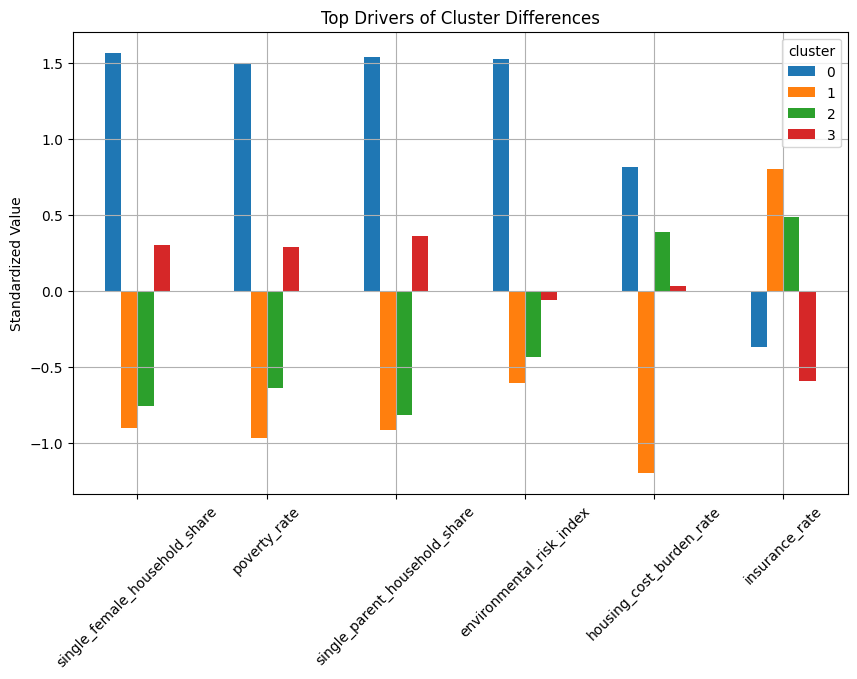

In [ ]:
import matplotlib.pyplot as plt

top_features = cluster_profiles.head(6).index

cluster_profiles.loc[top_features, [0,1,2,3]].plot(kind='bar', figsize=(10,6))
plt.title("Top Drivers of Cluster Differences")
plt.ylabel("Standardized Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# --- Explore multiple K values and cluster profiles ---

import pandas as pd
from sklearn.cluster import KMeans

X = X_scaled_df.copy()
target_col = 'Poor Mental Health Among Adults (2023)'

# Choose K values to explore
k_values = [3, 4, 5, 6]

results = {}

for k in k_values:
    print("\n" + "="*50)
    print(f"🔹 K = {k}")
    print("="*50)

    # -------------------------
    # Fit KMeans
    # -------------------------
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    # Attach to dataframe
    df_temp = df_cluster_ready.copy()
    df_temp['cluster'] = labels

    # -------------------------
    # Cluster counts
    # -------------------------
    print("\nCluster counts:")
    display(df_temp['cluster'].value_counts().sort_index().to_frame('count'))

    # -------------------------
    # Target summary
    # -------------------------
    if target_col in df_temp.columns:
        print(f"\nAverage {target_col} by cluster:")
        display(
            df_temp.groupby('cluster')[target_col]
            .agg(['count', 'mean', 'median', 'min', 'max'])
            .round(3)
        )

    # -------------------------
    # Cluster profiles
    # -------------------------
    feature_cols = X.columns.tolist()

    cluster_profile = (
        df_temp.groupby('cluster')[feature_cols]
        .mean()
        .T
    )

    # Add max difference across clusters (useful for interpretation)
    cluster_profile['max_difference'] = cluster_profile.max(axis=1) - cluster_profile.min(axis=1)
    cluster_profile = cluster_profile.sort_values(by='max_difference', ascending=False)

    print("\nTop differentiating features:")
    display(cluster_profile.head(8).round(3))

    # Save results if you want to reference later
    results[k] = {
        'df': df_temp,
        'profile': cluster_profile
    }

print("\nDone exploring K values.")


🔹 K = 3

Cluster counts:


,count
cluster,
0,40
1,98
2,101



Average Poor Mental Health Among Adults (2023) by cluster:


,count,mean,median,min,max
cluster,,,,,
0,40,19.995,20.141,13.243,24.315
1,98,18.469,18.244,13.975,22.351
2,101,15.711,15.703,11.216,21.393



Top differentiating features:


...


Average Poor Mental Health Among Adults (2023) by cluster:


,count,mean,median,min,max
cluster,,,,,
0,48,15.730,16.110,11.216,19.098
1,39,20.000,20.151,13.243,24.315
2,36,19.202,19.091,16.290,22.351
3,54,15.642,15.196,13.021,19.754
4,1,21.393,21.393,21.393,21.393
5,61,18.102,18.132,13.975,21.642



Top differentiating features:


cluster,0,1,2,3,4,5,max_difference
health_workers_per_capita,-0.216,0.277,-0.119,0.139,10.538,-0.233,10.771
single_parent_household_share,-1.013,1.546,0.596,-0.784,-1.513,0.175,3.059
single_female_household_share,-0.986,1.573,0.413,-0.733,-1.210,0.195,2.783
poverty_rate,-1.047,1.497,0.658,-0.616,-0.993,0.041,2.543
insurance_rate,0.839,-0.339,-1.577,0.477,0.596,0.055,2.417
environmental_risk_index,-0.697,1.574,-0.244,-0.402,-0.691,0.053,2.271
bachelors_or_higher_rate,0.232,-0.765,-0.481,1.294,0.594,-0.566,2.059
housing_cost_burden_rate,-1.194,0.789,0.551,0.471,-0.975,-0.291,1.983



Done exploring K values.


In [ ]:
# --- K = 4 clustering with district tracking ---

from sklearn.cluster import KMeans

# Copy base dataframe
df_k4 = df_cluster_ready.copy()

# -------------------------------------------------
# 1. Run KMeans (k = 4)
# -------------------------------------------------
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled_df)

df_k4['cluster'] = labels

# -------------------------------------------------
# 2. Print districts in each cluster
# -------------------------------------------------
print("\n" + "="*60)
print("DISTRICTS BY CLUSTER (k = 4)")
print("="*60)

for cluster_id in sorted(df_k4['cluster'].unique()):
    print(f"\n🔹 Cluster {cluster_id}")
    print("-"*40)

    districts = df_k4[df_k4['cluster'] == cluster_id]['feature label'].tolist()

    for d in districts:
        print(d)

# -------------------------------------------------
# 3. Filter Jacksonville districts
# -------------------------------------------------
print("\n" + "="*60)
print("JACKSONVILLE DISTRICTS")
print("="*60)

jax_df = df_k4[df_k4['feature label'].str.contains("Jacksonville", case=False, na=False)]

display(
    jax_df[['feature label', 'cluster', 'Poor Mental Health Among Adults (2023)']]
    .sort_values(by='cluster')
)

# -------------------------------------------------
# 4. Group Jacksonville districts by cluster
# -------------------------------------------------
print("\n" + "="*60)
print("JACKSONVILLE DISTRICTS BY CLUSTER")
print("="*60)

for cluster_id in sorted(jax_df['cluster'].unique()):
    print(f"\n🔹 Cluster {cluster_id}")
    print("-"*40)

    districts = jax_df[jax_df['cluster'] == cluster_id]['feature label'].tolist()

    for d in districts:
        print(d)

print("\nDone.")


DISTRICTS BY CLUSTER (k = 4)

🔹 Cluster 0
----------------------------------------
Council District 1, Newark, OH
Council District 2, Newark, OH
Council District 5, Lancaster, OH
Council District 1, Whitehall, OH
Council District 2, Whitehall, OH
Council District 4, Reynoldsburg, OH
Council District 8, Indianapolis, IN
Council District 9, Indianapolis, IN
Council District 5, Indianapolis, IN
Council District 12, Indianapolis, IN
Council District 13, Indianapolis, IN
Council District 15, Indianapolis, IN
Council District 18, Indianapolis, IN
Council District 19, Indianapolis, IN
Council District 10, Jacksonville, FL
Council District 9, Jacksonville, FL
Council District 1, Louisville, KY
Council District 3, Louisville, KY
Council District 4, Louisville, KY
Council District 5, Louisville, KY
Council District 6, Louisville, KY
Council District 15, Louisville, KY
Council District 1, Miami, FL
Council District 5, Miami, FL
Council District 4, Miami, FL
Council District 3, Miami, FL
Miami, F

,feature label,cluster,Poor Mental Health Among Adults (2023)
109,"Council District 10, Jacksonville, FL",0,21.6494
122,"Council District 9, Jacksonville, FL",0,21.5643
114,"Council District 3, Jacksonville, FL",1,17.0087
113,"Council District 2, Jacksonville, FL",1,17.2052
119,"Council District 6, Jacksonville, FL",1,16.3546
110,"Council District 11, Jacksonville, FL",2,16.4130
116,"Council District 13, Jacksonville, FL",2,16.6749
111,"Council District 12, Jacksonville, FL",3,19.3179
115,"Council District 1, Jacksonville, FL",3,20.4307
112,"Council District 14, Jacksonville, FL",3,19.6287



JACKSONVILLE DISTRICTS BY CLUSTER

🔹 Cluster 0
----------------------------------------
Council District 10, Jacksonville, FL
Council District 9, Jacksonville, FL

🔹 Cluster 1
----------------------------------------
Council District 2, Jacksonville, FL
Council District 3, Jacksonville, FL
Council District 6, Jacksonville, FL

🔹 Cluster 2
----------------------------------------
Council District 11, Jacksonville, FL
Council District 13, Jacksonville, FL

🔹 Cluster 3
----------------------------------------
Council District 12, Jacksonville, FL
Council District 14, Jacksonville, FL
Council District 1, Jacksonville, FL
Council District 4, Jacksonville, FL
Council District 5, Jacksonville, FL
Council District 7, Jacksonville, FL
Council District 8, Jacksonville, FL
Jacksonville, FL

Done.


In [ ]:
# --- Full export: K=4 clustering + labels + sorted CSV ---

import pandas as pd
from sklearn.cluster import KMeans

# -------------------------------
# 1. Run KMeans (k = 4)
# -------------------------------
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled_df)

# -------------------------------
# 2. Define target column
# -------------------------------
target_col = 'Poor Mental Health Among Adults (2023)'

# -------------------------------
# 3. Create export dataframe
# -------------------------------
df_export = pd.DataFrame({
    'feature label': df['feature label'],
    'cluster': labels,
    target_col: df[target_col]
})

# -------------------------------
# 4. Add descriptive cluster labels
# (adjust names if needed based on your interpretation)
# -------------------------------
cluster_names = {
    0: "Extreme Risk",
    1: "Low Risk",
    2: "Moderate",
    3: "Moderate-High Risk"
}

df_export['cluster_label'] = df_export['cluster'].map(cluster_names)

# -------------------------------
# 5. Sort for readability
# -------------------------------
df_export_sorted = df_export.sort_values(by=['cluster', target_col], ascending=[True, False])

# -------------------------------
# 6. Save to CSV
# -------------------------------
file_name = "district_clusters_k4_full.csv"
df_export_sorted.to_csv(file_name, index=False)

# -------------------------------
# 7. Preview
# -------------------------------
print(f"Saved: {file_name}")
display(df_export_sorted.head(20))

Saved: district_clusters_k4_full.csv


,feature label,cluster,Poor Mental Health Among Adults (2023),cluster_label
173,"Council District 21, Nashville, TN",0,24.3146,Extreme Risk
163,"Council District 17, Nashville, TN",0,23.1416,Extreme Risk
134,"Council District 6, Louisville, KY",0,22.4983,Extreme Risk
26,"Council District 1, Newark, OH",0,22.4126,Extreme Risk
204,"Council District 7, Philadelphia, PA",0,22.0369,Extreme Risk
45,"Council District 2, Whitehall, OH",0,21.8074,Extreme Risk
43,"Council District 1, Whitehall, OH",0,21.7364,Extreme Risk
172,"Council District 2, Nashville, TN",0,21.6817,Extreme Risk
109,"Council District 10, Jacksonville, FL",0,21.6494,Extreme Risk
207,"Council District 3, Philadelphia, PA",0,21.5830,Extreme Risk
